# Comparaison des modèles

## Modèles Machine Learning

Ces deux premières figures ne portent que sur les **baselines Machine Learning** (régression logistique, KNN, SVM, Random Forest, XGBoost) — pour la partie « machine learning seule » du rapport. Les modèles deep learning sont comparés dans les sections suivantes.

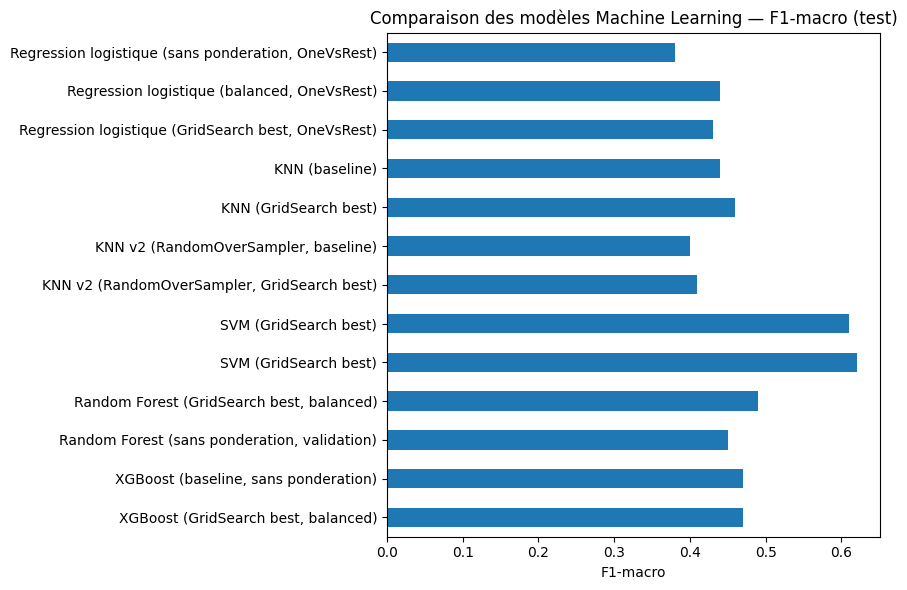

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('model_comparison.csv')
# le CSV utilise la virgule décimale ("0,90") -> on convertit en float pour pouvoir tracer
for c in ['accuracy', 'f1_macro', 'f1_covid', 'f1_normal', 'f1_lung_opacity', 'f1_viral_pneumonia']:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.', regex=False), errors='coerce')

# ne garder que les modèles Machine Learning (les modèles DL du CSV sont traités plus bas)
motif_dl = r"CNN|inception|VGG|ResNet|EfficientNet|CovidNet"
df = df[~df['modele'].str.contains(motif_dl, case=False, regex=True)].reset_index(drop=True)

df.plot(kind='barh', x='modele', y='f1_macro', legend=False, figsize=(9, 6))
plt.gca().invert_yaxis()  # garder l'ordre du CSV, de haut en bas
plt.xlabel('F1-macro')
plt.ylabel('')
plt.title('Comparaison des modèles Machine Learning — F1-macro (test)')
plt.tight_layout()
plt.show()

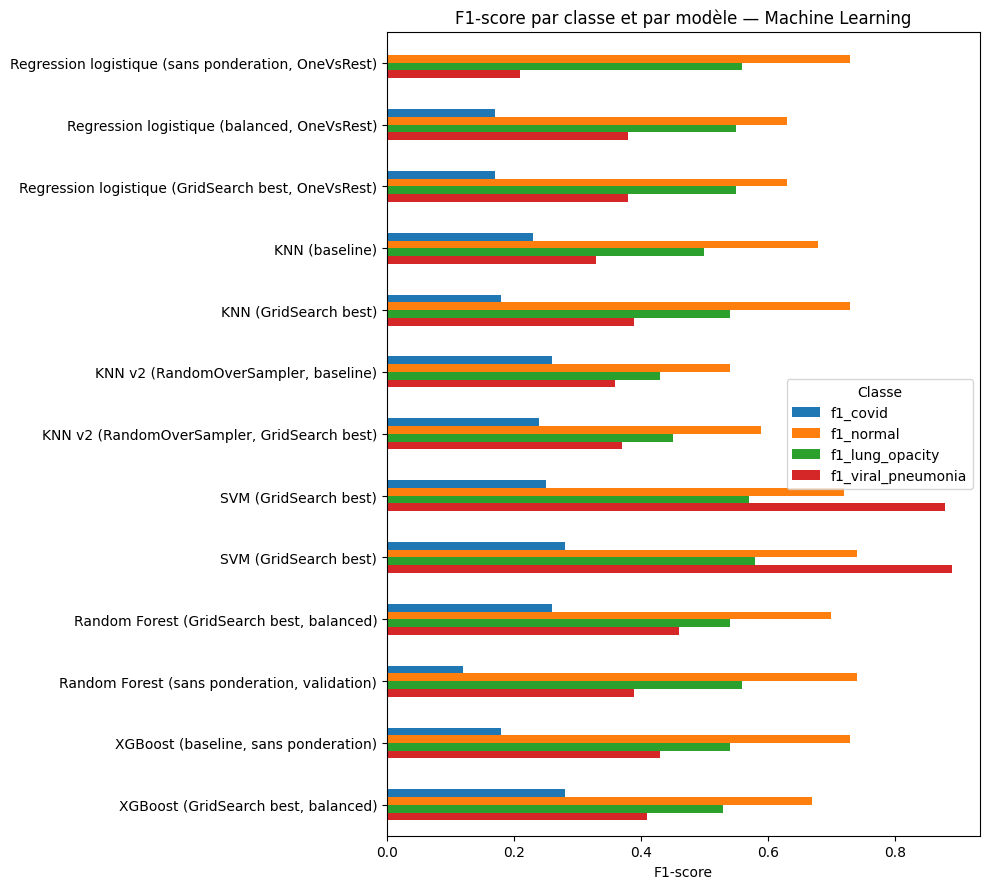

In [2]:
metrics = ['f1_covid', 'f1_normal', 'f1_lung_opacity', 'f1_viral_pneumonia']
df.set_index('modele')[metrics].plot(kind='barh', figsize=(10, 9))
plt.gca().invert_yaxis()  # garder l'ordre du CSV, de haut en bas
plt.xlabel('F1-score')
plt.ylabel('')
plt.title('F1-score par classe et par modèle — Machine Learning')
plt.legend(title='Classe')
plt.tight_layout()
plt.show()

## Comparaison par F1-macro

Le F1-macro (moyenne non pondérée des F1 par classe) est notre métrique de référence : contrairement à l'accuracy, il ne se laisse pas tirer vers le haut par la classe majoritaire (Normal), et pénalise un modèle qui rate une classe minoritaire comme COVID.

On consolide ici **tous les modèles** dans un seul tableau :

- ceux déjà présents dans `model_comparison.csv` (baselines ML + CNN « niveaux » + inception V3 + VGG16) ;
- les modèles deep learning restants, lus dans les notebooks de chaque dossier — **F1-macro sur le test** (support 2084) : `CNN v1 (from scratch)`, `EfficientNet`, les 4 variantes `ResNet` (score après fine-tuning), et `CovidNet`.

> *CovidNet ne calcule dans son notebook qu'un F1 pondéré (weighted) ; son F1-macro (0,83) a été **recalculé à partir de sa matrice de confusion sur le test** — le F1 weighted correspondant retombe bien sur 0,846, ce qui valide la reconstruction.*

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Table maître (baselines ML + CNN niveaux + inception + VGG16) ---
data = pd.read_csv("model_comparison.csv")
# coercition numérique robuste (au cas où le CSV utilise la virgule décimale)
for c in ["accuracy", "f1_macro", "f1_covid", "f1_normal", "f1_lung_opacity", "f1_viral_pneumonia"]:
    data[c] = pd.to_numeric(data[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")

# --- Modèles deep learning restants, lus dans les notebooks de chaque dossier ---
# F1-macro sur le jeu de test (support 2084). ResNet = score après fine-tuning.
ajouts_dl = pd.DataFrame([
    {"modele": "CNN v1 (from scratch)",    "f1_macro": 0.79},   # cnn_v1_maxime.ipynb
    {"modele": "EfficientNet",             "f1_macro": 0.82},   # EfficientNet/EfficientNet.ipynb
    {"modele": "ResNet50 (balanced)",      "f1_macro": 0.875},  # ResNet/ResNet_50.ipynb
    {"modele": "ResNet50 (unbalanced)",    "f1_macro": 0.876},  # ResNet/ResNet_50_unbalanced.ipynb
    {"modele": "ResNet101V2 (balanced)",   "f1_macro": 0.877},  # ResNet/ResNet101V2.ipynb
    {"modele": "ResNet101V2 (unbalanced)", "f1_macro": 0.873},  # ResNet/ResNet101V2_unbalanced.ipynb
    {"modele": "CovidNet",                 "f1_macro": 0.834},  # recalculé depuis sa matrice de confusion (CovidNet_scratch_v2, test)
])
data = pd.concat([data, ajouts_dl], ignore_index=True)

# --- Étiquette ML vs Deep Learning (par mot-clé dans le nom du modèle) ---
EST_DL = re.compile(r"CNN|inception|VGG|ResNet|EfficientNet|CovidNet", re.I)
data["type"] = data["modele"].apply(
    lambda m: "Deep Learning" if EST_DL.search(m) else "Machine Learning"
)

# --- Palette daltonien-safe (Okabe-Ito) et helper de tracé ---
BLEU, ORANGE, INK = "#0072B2", "#E69F00", "#222222"

def barh_f1(sub, couleurs, titre, figsize, fs_label=9):
    """Barres horizontales de f1_macro, triées, avec valeur en bout de barre."""
    sub = sub.sort_values("f1_macro").reset_index(drop=True)
    y = np.arange(len(sub))
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(y, sub["f1_macro"], color=couleurs(sub), height=0.72, zorder=3)
    for yi, v in zip(y, sub["f1_macro"]):
        ax.text(v + 0.008, yi, f"{v:.2f}", va="center", ha="left", fontsize=fs_label, color=INK)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["modele"])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("F1-macro (test)")
    ax.set_title(titre, fontsize=12, fontweight="bold")
    ax.grid(axis="x", color="#cccccc", lw=0.6, zorder=0)
    ax.set_axisbelow(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    return fig, ax

print(f"{len(data)} modèles  —  "
      f"{(data.type=='Deep Learning').sum()} deep learning, "
      f"{(data.type=='Machine Learning').sum()} machine learning")
data[["modele", "type", "f1_macro"]].sort_values("f1_macro", ascending=False)

33 modèles  —  20 deep learning, 13 machine learning


,modele,type,f1_macro
15,CNN 4 niveaux,Deep Learning,0.920
22,CNN 512,Deep Learning,0.920
18,CNN 3 niveaux,Deep Learning,0.910
16,CNN 3 niveaux + L2+W,Deep Learning,0.910
14,CNN 4 niveaux + L2,Deep Learning,0.910
17,CNN 3 niveaux + L2,Deep Learning,0.910
21,VGG16,Deep Learning,0.910
23,CNN 1024,Deep Learning,0.910
24,CNN 256 (tuned),Deep Learning,0.900
13,CNN 4 niveaux + L2+W,Deep Learning,0.900


### F1-macro — modèles Deep Learning uniquement

Comparaison entre nos modèles deep learning seuls (CNN maison, transfer learning : VGG16, inception, ResNet, EfficientNet).

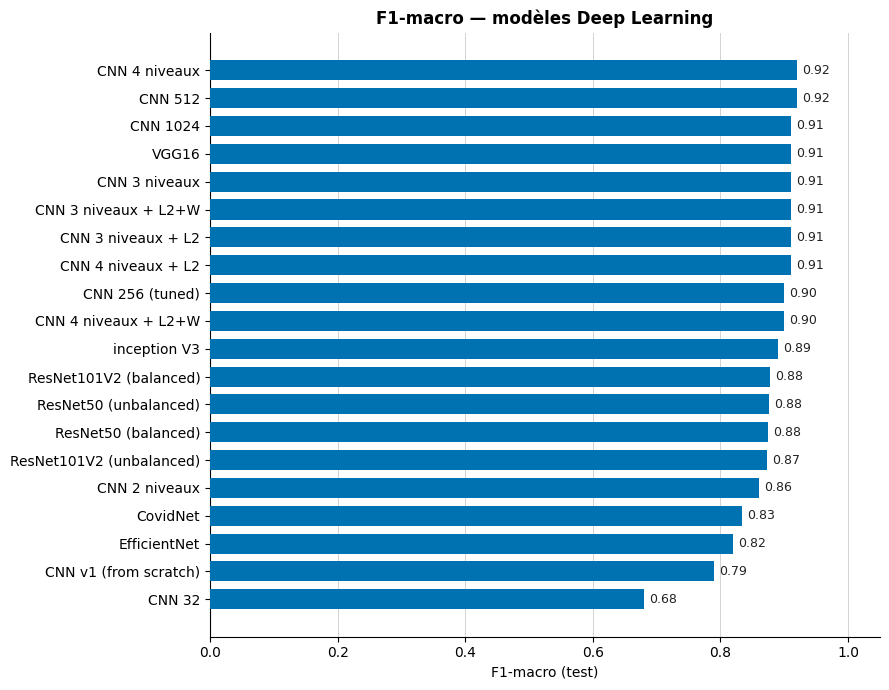

In [4]:
dl = data[data["type"] == "Deep Learning"]

barh_f1(dl, lambda s: BLEU,
        "F1-macro — modèles Deep Learning", figsize=(9, 7))
plt.tight_layout()
plt.show()

### F1-macro — comparaison globale Machine Learning vs Deep Learning

Tous les modèles sur une même figure, colorés par famille. On voit nettement le bloc deep learning (bleu) se détacher au-dessus des baselines de machine learning (orange).

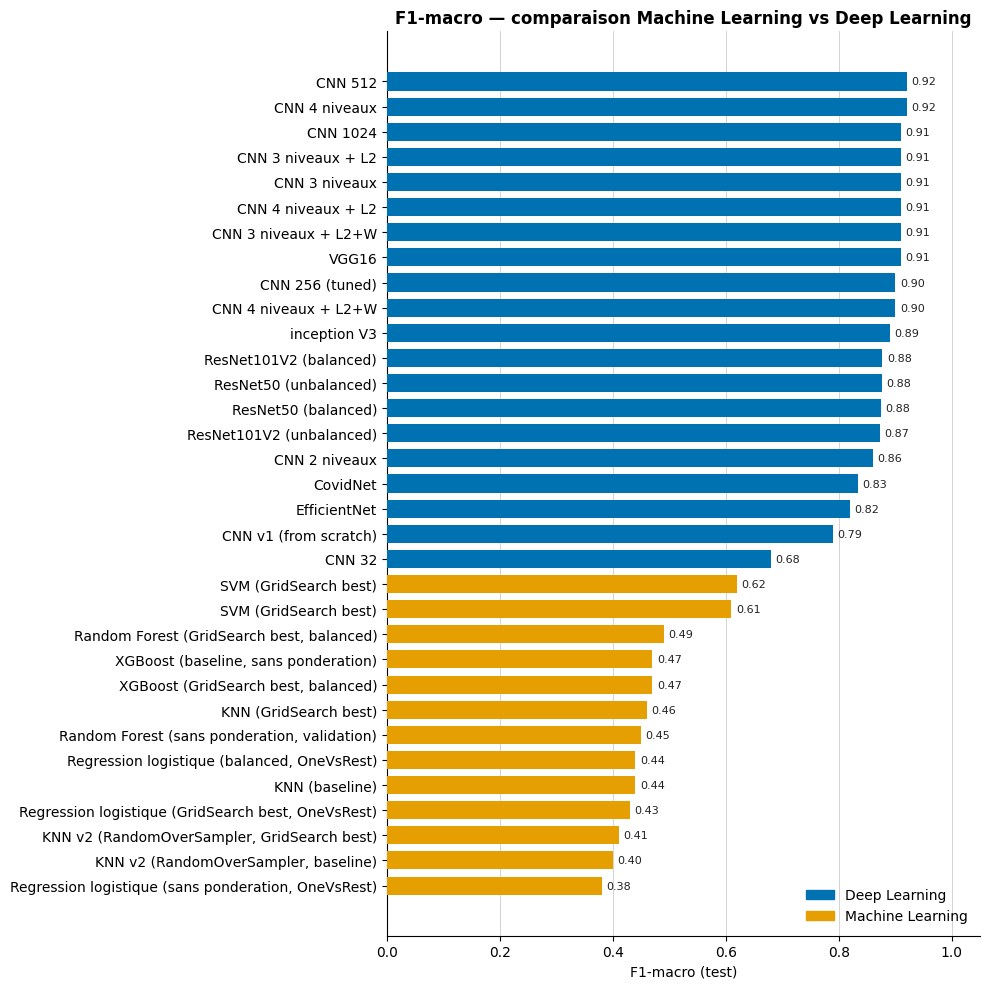

In [5]:
fig, ax = barh_f1(
    data,
    lambda s: s["type"].map({"Deep Learning": BLEU, "Machine Learning": ORANGE}).values,
    "F1-macro — comparaison Machine Learning vs Deep Learning",
    figsize=(10, 10), fs_label=8,
)
ax.legend(
    handles=[Patch(color=BLEU, label="Deep Learning"),
             Patch(color=ORANGE, label="Machine Learning")],
    loc="lower right", frameon=False,
)
plt.tight_layout()
plt.show()

## F1-macro par époque

Planche des courbes F1-macro (entraînement vs validation) par époque, assemblées depuis les PNG déjà sauvegardés (aucun modèle réexécuté). Sont inclus tous les modèles disposant d'une courbe : les **CNN** (32 → 1024, dont *256 tuned*), **inception V3**, **VGG16**, et les **4 ResNet** (courbes fournies par Noura).

*Absents (pas de courbe F1/époque) : CNN v1 (from scratch), EfficientNet, CovidNet.*

figure sauvegardée -> reports/figures/f1_par_epoque.png


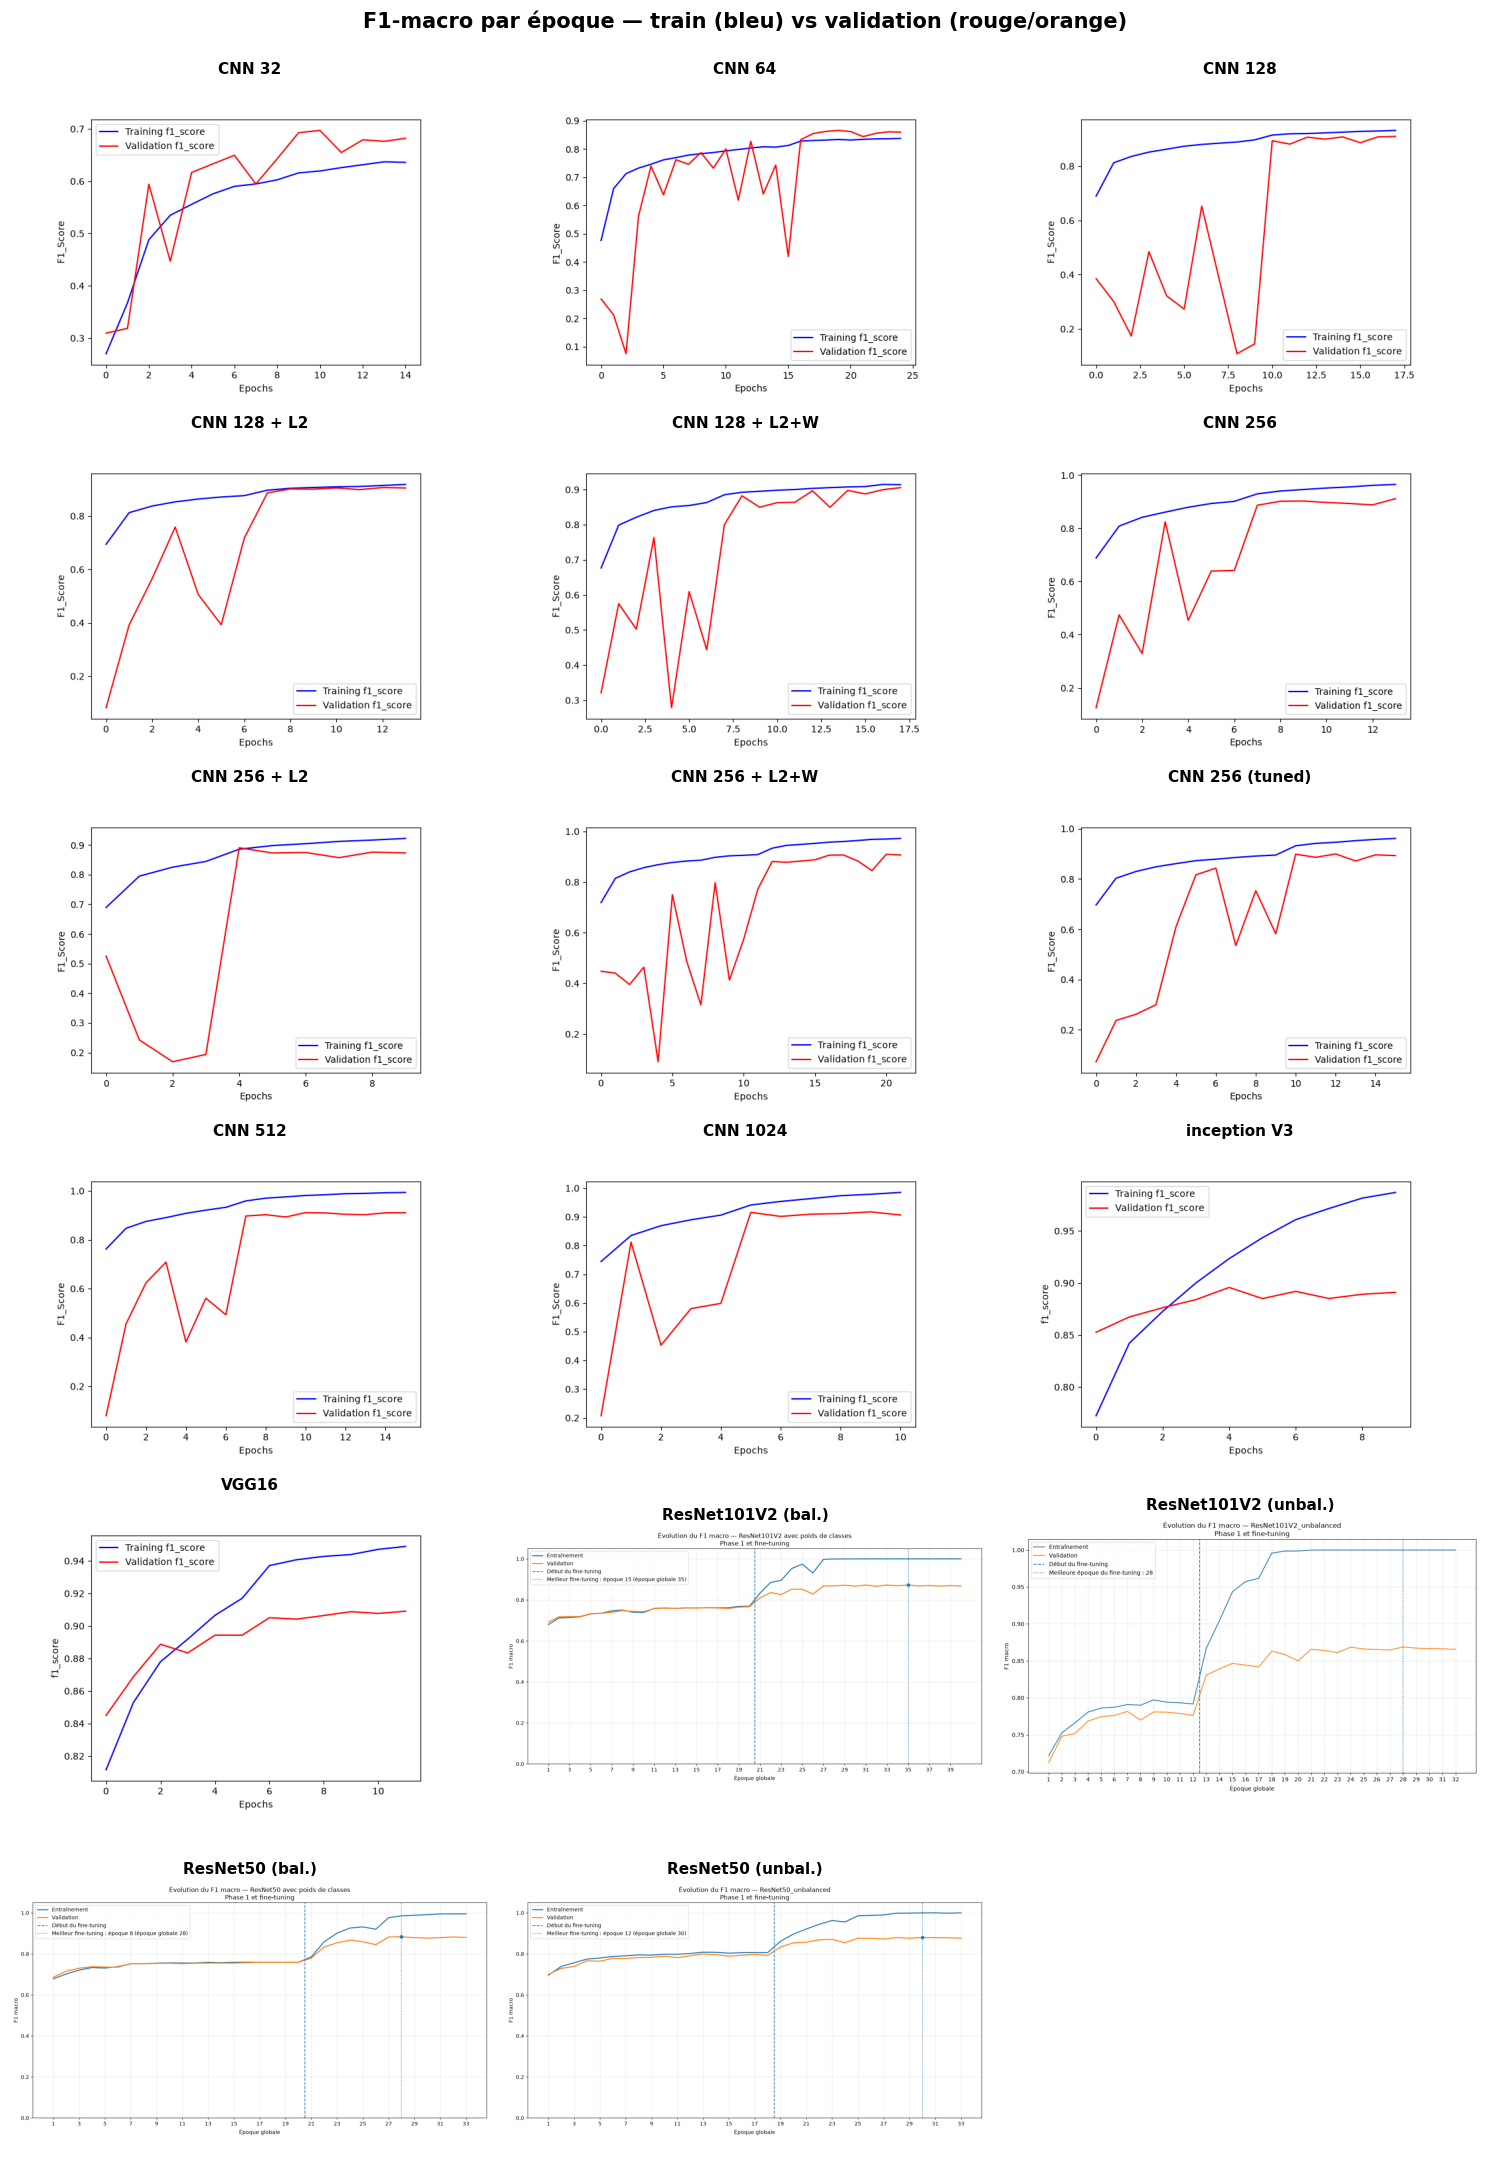

In [6]:
import os
import matplotlib.image as mpimg

# (nom affiché, PNG relatif au dossier models/) — modèles avec une courbe F1/époque
figs_epoque = [
    ("CNN 32",          "cnn32/cnn_32.png"),
    ("CNN 64",          "cnn64/cnn_64.png"),
    ("CNN 128",         "cnn128/cnn_128.png"),
    ("CNN 128 + L2",    "cnn128/cnn_128_l2.png"),
    ("CNN 128 + L2+W",  "cnn128/cnn_128_l2_weight.png"),
    ("CNN 256",         "cnn256/cnn_256.png"),
    ("CNN 256 + L2",    "cnn256/cnn_256_l2.png"),
    ("CNN 256 + L2+W",  "cnn256/cnn_256_l2_weight.png"),
    ("CNN 256 (tuned)", "cnn256_tuned/cnn_256.png"),
    ("CNN 512",         "cnn512/cnn_512.png"),
    ("CNN 1024",        "cnn1024/cnn_1024.png"),
    ("inception V3",    "inceptionv3/inceptionv3.png"),
    ("VGG16",           "vgg16/vgg16.png"),
    ("ResNet101V2 (bal.)",   "../reports/figures/f1ep_resnet101_bal.png"),
    ("ResNet101V2 (unbal.)", "../reports/figures/f1ep_resnet101_unbal.png"),
    ("ResNet50 (bal.)",      "../reports/figures/f1ep_resnet50_bal.png"),
    ("ResNet50 (unbal.)",    "../reports/figures/f1ep_resnet50_unbal.png"),
]

ncols = 3
nrows = int(np.ceil(len(figs_epoque) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.7 * nrows))
for ax, (titre, path) in zip(axes.flat, figs_epoque):
    ax.imshow(mpimg.imread(path))
    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.axis('off')
for ax in axes.flat[len(figs_epoque):]:
    ax.axis('off')

fig.suptitle('F1-macro par époque — train (bleu) vs validation (rouge/orange)', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
os.makedirs('../reports/figures', exist_ok=True)
fig.savefig('../reports/figures/f1_par_epoque.png', dpi=105, bbox_inches='tight')
print('figure sauvegardée -> reports/figures/f1_par_epoque.png')
plt.show()

## Matrices de confusion — Machine Learning vs Deep Learning

Matrices de confusion sur le **jeu de test** (2084 images), une figure par famille. Les effectifs ont été **relevés dans les notebooks de chaque modèle** (sorties texte ou heatmaps annotées), puis re-tracés ici en style uniforme. Chaque vignette affiche l'accuracy et le F1-macro **recalculés à partir de la matrice** — donc cohérents avec elle.

Chaque matrice a été validée par ses sommes de lignes = effectifs réels du test par classe : COVID 337, Lung_Opacity 599, Normal 1014, Viral Pneumonia 134.

> ⚠️ **Incohérence à trancher — SVM.** Le F1-macro recalculé depuis la matrice du SVM disponible (`svm_weighted`) vaut **0,47**, alors que `model_comparison.csv` annonce **0,62** pour « SVM (GridSearch best) ». Aucune matrice de confusion sauvegardée ne correspond à 0,62 (les notebooks SVM donnent 0,45–0,47). À vérifier : soit la valeur 0,62 de la table est à corriger, soit la matrice du bon SVM n'a pas été sauvegardée.

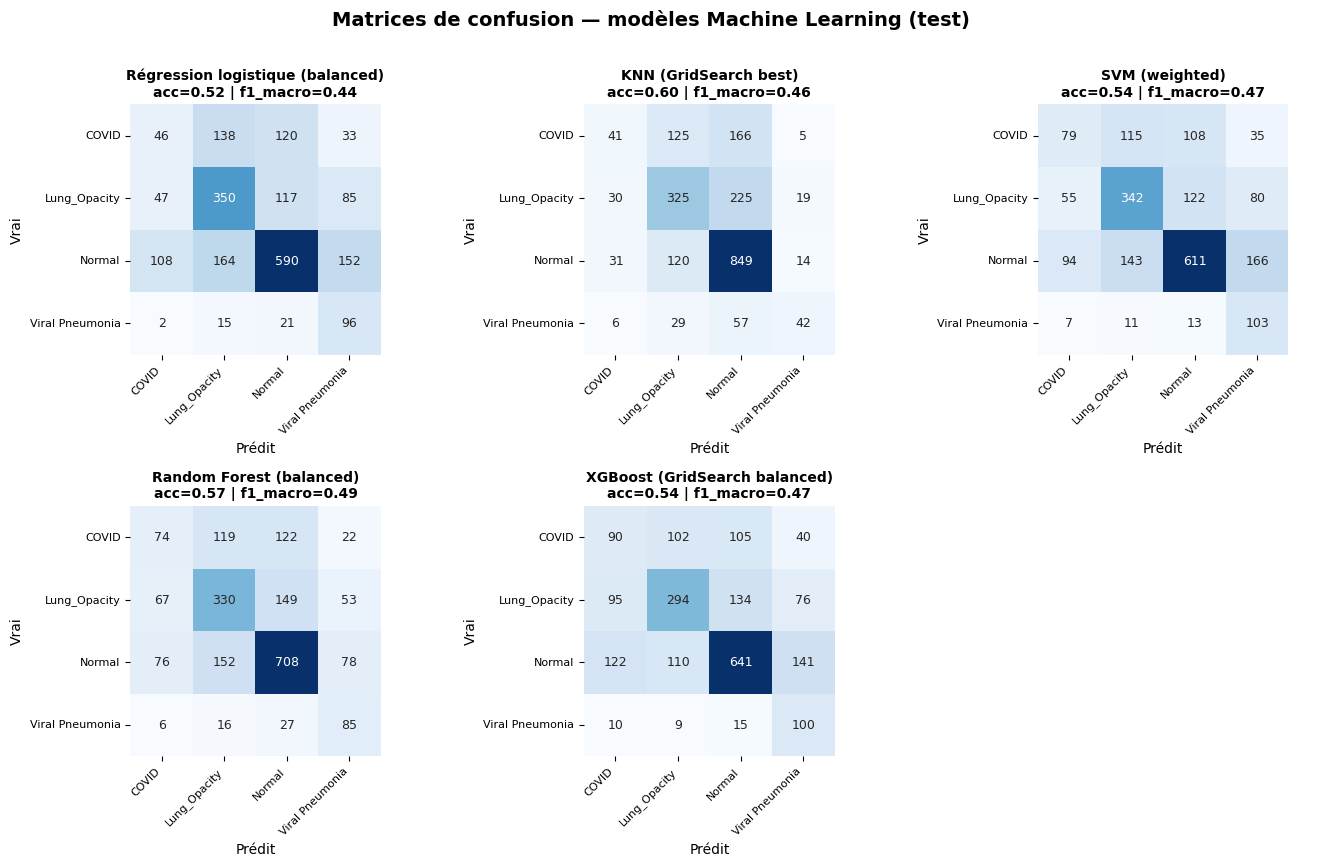

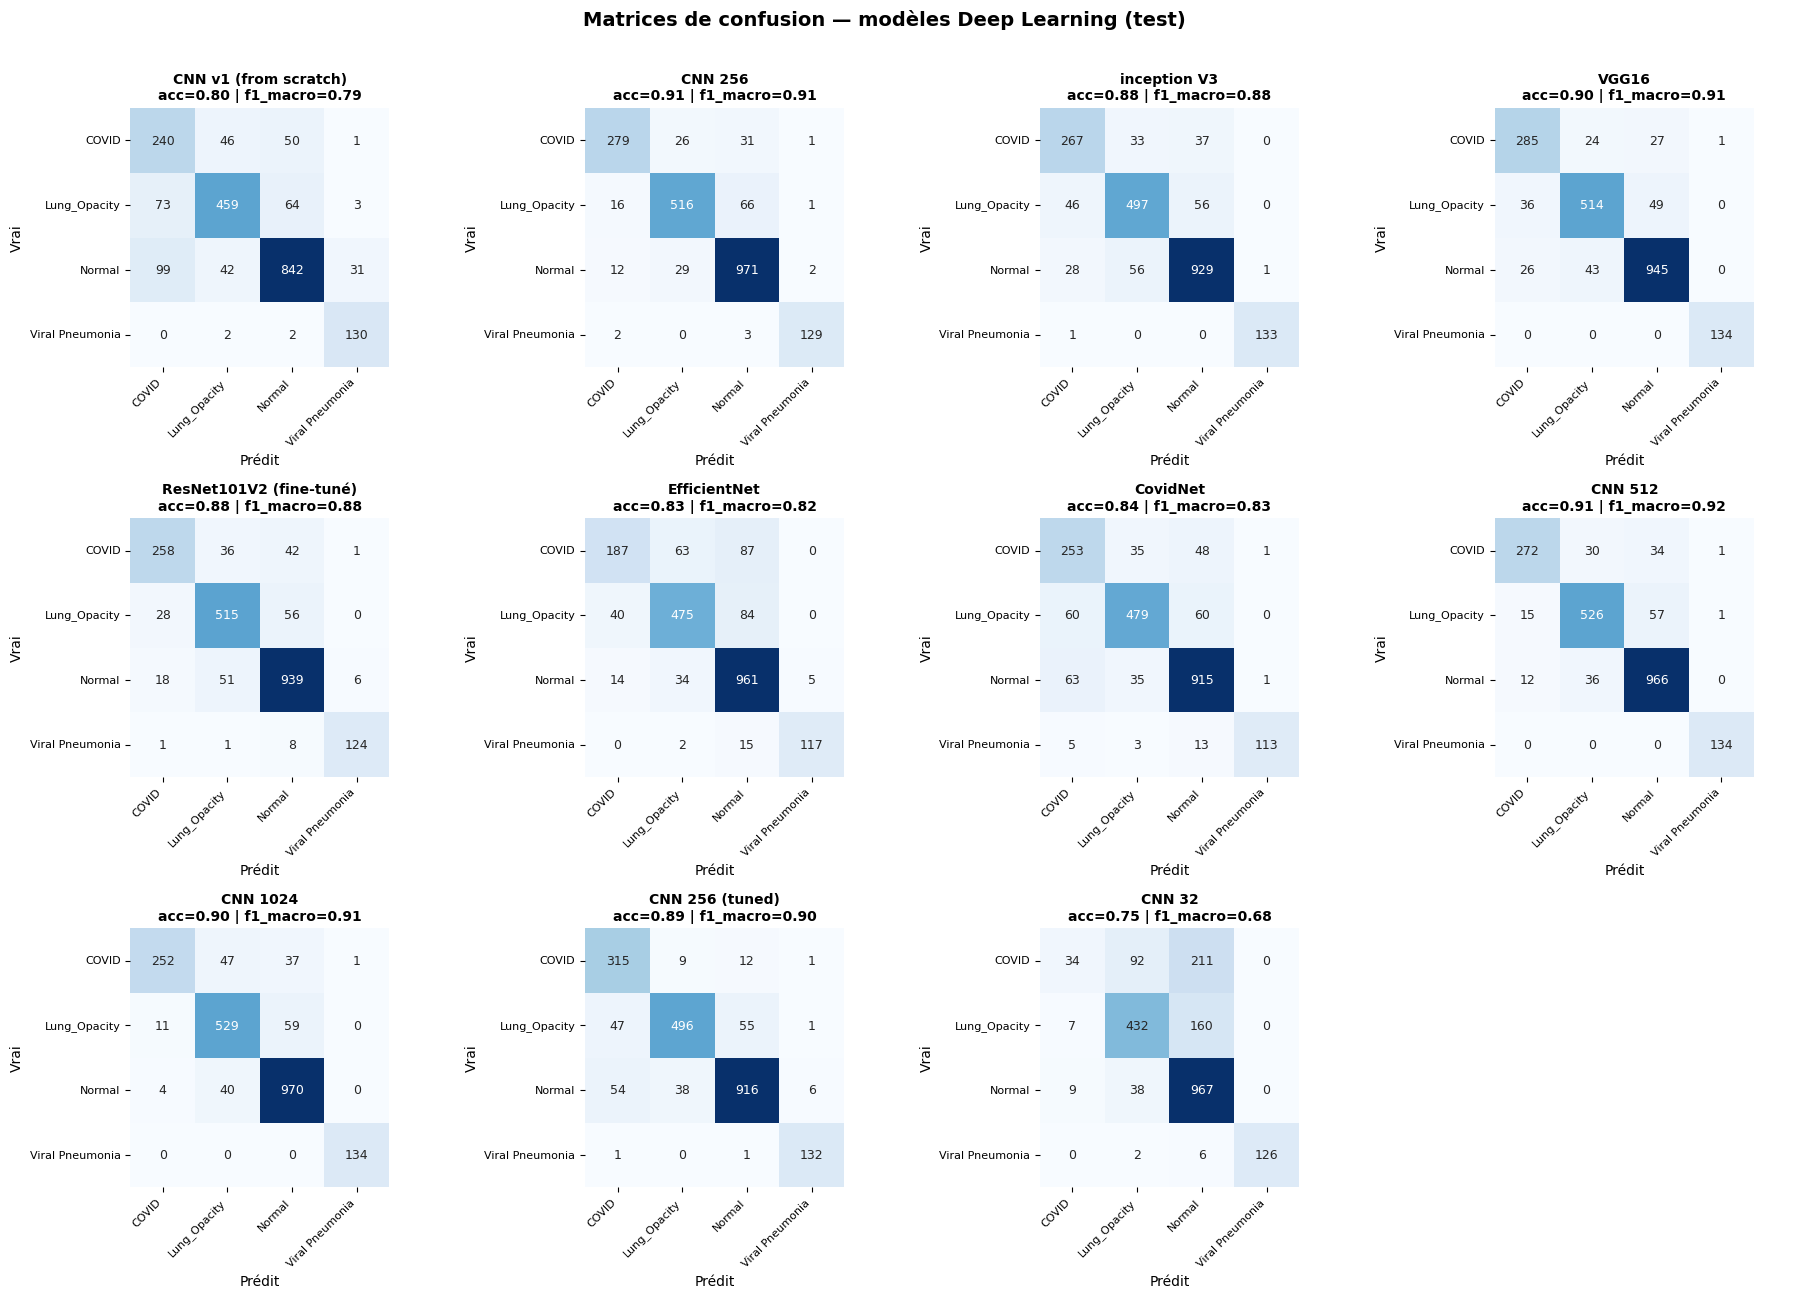

figures sauvegardées -> reports/figures/cm_machine_learning.png, cm_deep_learning.png


In [7]:
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

CLASSES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

# Matrices de confusion sur le TEST (lignes = vrai, colonnes = prédit),
# relevées dans le notebook de chaque modèle. type = "ML" ou "DL".
CM = {
    "Régression logistique (balanced)": ("ML", [[46, 138, 120, 33], [47, 350, 117, 85], [108, 164, 590, 152], [2, 15, 21, 96]]),
    "KNN (GridSearch best)":            ("ML", [[41, 125, 166, 5], [30, 325, 225, 19], [31, 120, 849, 14], [6, 29, 57, 42]]),
    "SVM (weighted)":                   ("ML", [[79, 115, 108, 35], [55, 342, 122, 80], [94, 143, 611, 166], [7, 11, 13, 103]]),
    "Random Forest (balanced)":         ("ML", [[74, 119, 122, 22], [67, 330, 149, 53], [76, 152, 708, 78], [6, 16, 27, 85]]),
    "XGBoost (GridSearch balanced)":    ("ML", [[90, 102, 105, 40], [95, 294, 134, 76], [122, 110, 641, 141], [10, 9, 15, 100]]),
    "CNN v1 (from scratch)":            ("DL", [[240, 46, 50, 1], [73, 459, 64, 3], [99, 42, 842, 31], [0, 2, 2, 130]]),
    "CNN 256":                          ("DL", [[279, 26, 31, 1], [16, 516, 66, 1], [12, 29, 971, 2], [2, 0, 3, 129]]),
    "inception V3":                     ("DL", [[267, 33, 37, 0], [46, 497, 56, 0], [28, 56, 929, 1], [1, 0, 0, 133]]),
    "VGG16":                            ("DL", [[285, 24, 27, 1], [36, 514, 49, 0], [26, 43, 945, 0], [0, 0, 0, 134]]),
    "ResNet101V2 (fine-tuné)":          ("DL", [[258, 36, 42, 1], [28, 515, 56, 0], [18, 51, 939, 6], [1, 1, 8, 124]]),
    "EfficientNet":                     ("DL", [[187, 63, 87, 0], [40, 475, 84, 0], [14, 34, 961, 5], [0, 2, 15, 117]]),
    "CovidNet":                         ("DL", [[253, 35, 48, 1], [60, 479, 60, 0], [63, 35, 915, 1], [5, 3, 13, 113]]),
    "CNN 512":                          ("DL", [[272, 30, 34, 1], [15, 526, 57, 1], [12, 36, 966, 0], [0, 0, 0, 134]]),
    "CNN 1024":                         ("DL", [[252, 47, 37, 1], [11, 529, 59, 0], [4, 40, 970, 0], [0, 0, 0, 134]]),
    "CNN 256 (tuned)":                  ("DL", [[315, 9, 12, 1], [47, 496, 55, 1], [54, 38, 916, 6], [1, 0, 1, 132]]),
    "CNN 32":                           ("DL", [[34, 92, 211, 0], [7, 432, 160, 0], [9, 38, 967, 0], [0, 2, 6, 126]]),
}

SUPPORTS = [337, 599, 1014, 134]  # effectifs test par classe -> contrôle des sommes de lignes


def _metrics_from_cm(cm):
    """Reconstruit (y_true, y_pred) depuis la matrice pour recalculer acc et f1_macro."""
    cm = np.asarray(cm)
    y_true, y_pred = [], []
    for i in range(4):
        for j in range(4):
            y_true += [i] * cm[i, j]
            y_pred += [j] * cm[i, j]
    return accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro")


def figure_cm(famille, titre, ncols, fichier_png):
    noms = [k for k, (typ, _) in CM.items() if typ == famille]
    n = len(noms)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.4 * nrows))
    axes = np.asarray(axes).reshape(-1)
    for ax, nom in zip(axes, noms):
        cm = np.asarray(CM[nom][1])
        assert list(cm.sum(axis=1)) == SUPPORTS, f"sommes de lignes inattendues pour {nom}"
        acc, f1 = _metrics_from_cm(cm)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, annot_kws={"size": 9})
        ax.set_title(f"{nom}\nacc={acc:.2f} | f1_macro={f1:.2f}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Prédit")
        ax.set_ylabel("Vrai")
        ax.tick_params(labelsize=8)
        for t in ax.get_xticklabels():
            t.set_rotation(45)
            t.set_ha("right")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(titre, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    os.makedirs("../reports/figures", exist_ok=True)
    fig.savefig(f"../reports/figures/{fichier_png}", dpi=115, bbox_inches="tight")
    plt.show()


figure_cm("ML", "Matrices de confusion — modèles Machine Learning (test)", 3, "cm_machine_learning.png")
figure_cm("DL", "Matrices de confusion — modèles Deep Learning (test)", 4, "cm_deep_learning.png")
print("figures sauvegardées -> reports/figures/cm_machine_learning.png, cm_deep_learning.png")

### F1-score par classe et par modèle — Deep Learning

Équivalent, pour le deep learning, de la figure « F1-score par classe » des baselines ML. Le F1 par classe est **recalculé à partir des matrices de confusion** ci-dessus (mêmes modèles), ce qui permet d'inclure EfficientNet, ResNet et CovidNet — absents des colonnes par classe du CSV. Les modèles sont triés par F1 moyen.

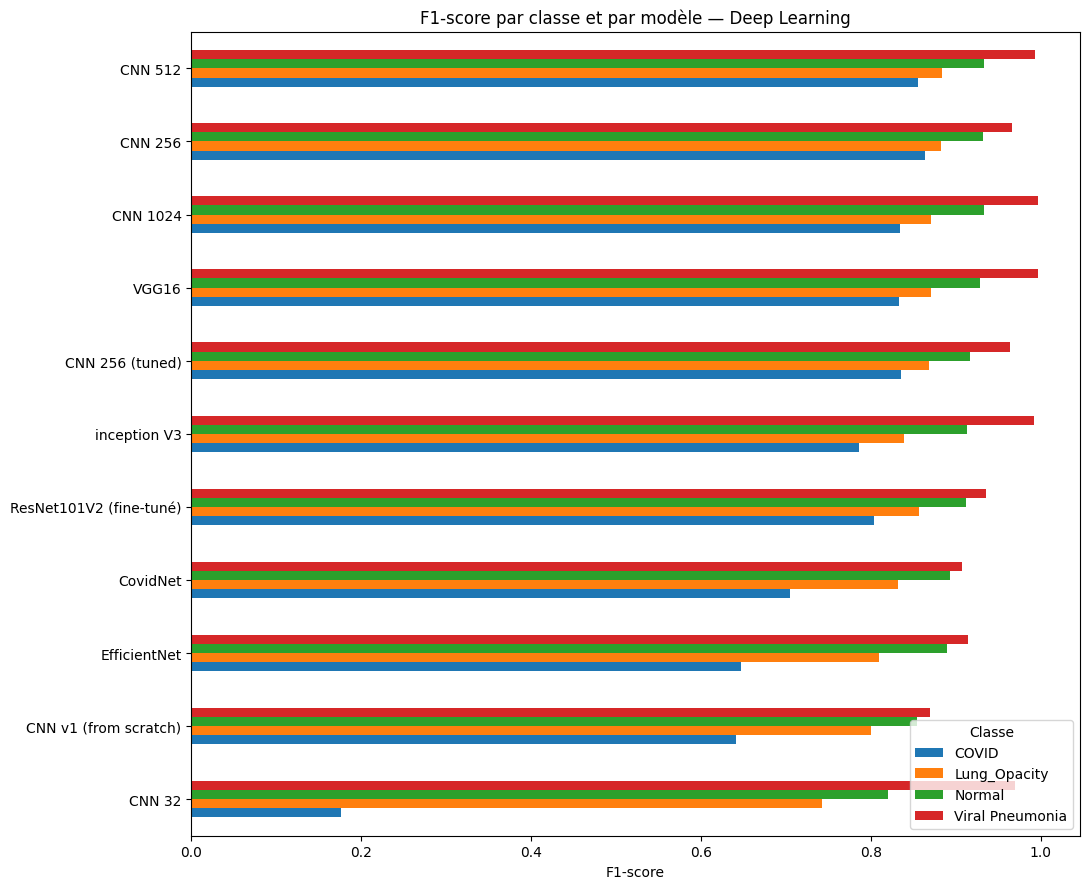

In [8]:
def _f1_par_classe(cm):
    """F1 par classe recalculé depuis une matrice de confusion 4x4."""
    cm = np.asarray(cm)
    y_true, y_pred = [], []
    for i in range(4):
        for j in range(4):
            y_true += [i] * cm[i, j]
            y_pred += [j] * cm[i, j]
    return f1_score(y_true, y_pred, average=None)

# lignes = modèles DL, colonnes = classes
dl_perclass = {nom: _f1_par_classe(cm) for nom, (typ, cm) in CM.items() if typ == "DL"}
perclass_df = pd.DataFrame(dl_perclass, index=CLASSES).T
perclass_df = perclass_df.loc[perclass_df.mean(axis=1).sort_values().index]  # tri par F1 moyen

perclass_df.plot(kind="barh", figsize=(11, 9))
plt.xlabel("F1-score")
plt.ylabel("")
plt.title("F1-score par classe et par modèle — Deep Learning")
plt.legend(title="Classe")
plt.tight_layout()
plt.show()

### Précision et rappel par classe et par modèle

Le F1 par classe combine deux informations qu'on sépare ici, toujours recalculées depuis les matrices de confusion :

- **Précision** (classe X) : parmi les images *prédites* X, quelle fraction est vraiment X → mesure les **fausses alertes**.
- **Rappel** (classe X) : parmi les images *réellement* X, quelle fraction est retrouvée → mesure les **cas manqués**.

Pour le dépistage COVID, le **rappel COVID** est prioritaire (ne pas rater de vrais cas). Les baselines ML ratent la majorité des COVID (rappel ≈ 0,1–0,3) là où le deep learning monte à 0,55–0,85.

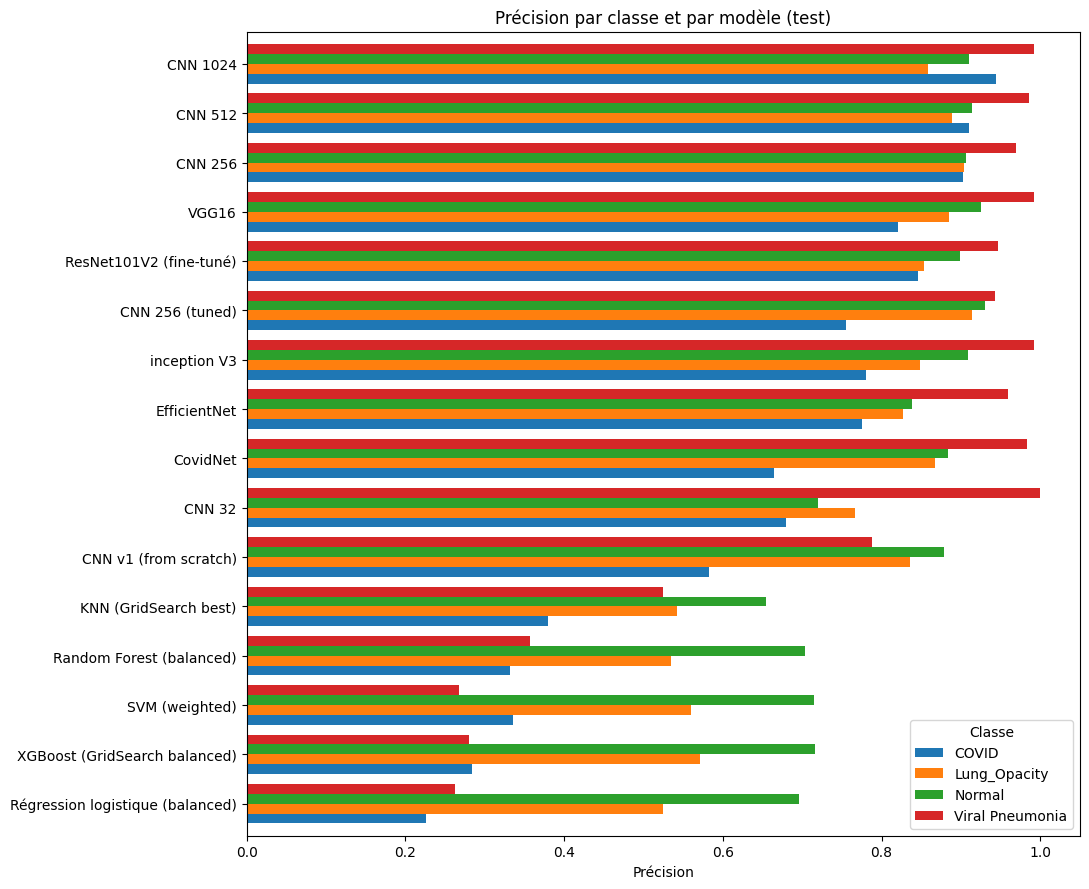

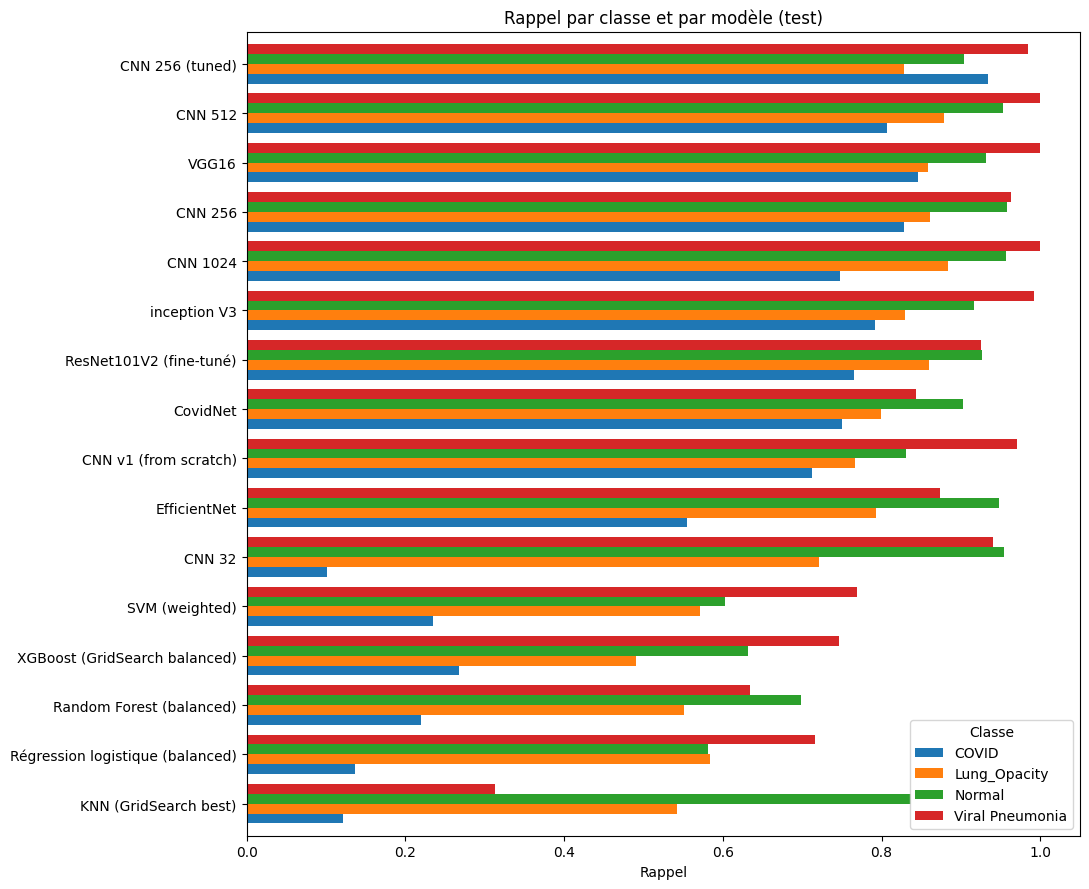

In [9]:
def _prec_rec(cm):
    cm = np.asarray(cm, dtype=float)
    precision = np.diag(cm) / cm.sum(axis=0)   # colonnes = prédits
    rappel = np.diag(cm) / cm.sum(axis=1)       # lignes = vrais
    return precision, rappel

def figure_prec_rappel(indice, titre, fichier_png):
    # indice : 0 = précision, 1 = rappel
    valeurs = {nom: _prec_rec(cm)[indice] for nom, (typ, cm) in CM.items()}
    df = pd.DataFrame(valeurs, index=CLASSES).T
    df = df.loc[df.mean(axis=1).sort_values().index]  # tri par score moyen
    df.plot(kind='barh', figsize=(11, 9), width=0.8)
    plt.xlim(0, 1.05)
    plt.xlabel(titre)
    plt.ylabel('')
    plt.title(f'{titre} par classe et par modèle (test)')
    plt.legend(title='Classe', loc='lower right')
    plt.tight_layout()
    os.makedirs('../reports/figures', exist_ok=True)
    plt.savefig(f'../reports/figures/{fichier_png}', dpi=130, bbox_inches='tight')
    plt.show()

figure_prec_rappel(0, 'Précision', 'rpt_precision.png')
figure_prec_rappel(1, 'Rappel', 'rpt_rappel.png')

## Grad-CAM par modèle

Planche comparant les cartes d'activation (Grad-CAM) : pour chaque modèle, une image originale et sa carte de chaleur, qui indique les zones sur lesquelles le modèle s'appuie pour décider. L'intérêt : vérifier que la décision repose bien sur les **champs pulmonaires** et non sur des artefacts (fond, bords, annotations).

**Couverture :**
- **CNN 256** et **CNN v1 (from scratch)** : Grad-CAM régénéré ici à partir des poids `.keras` sauvegardés (une image par classe).
- **CovidNet** et **ResNet101V2** : Grad-CAM récupéré directement des sorties de leurs notebooks.
- ⚠️ **inception V3, VGG16, EfficientNet** : non disponibles — ni poids `.keras` sauvegardés, ni figure Grad-CAM dans leur notebook. À ajouter en exécutant la cellule Grad-CAM de ces notebooks (leur code existe déjà).

*Note : les figures ne sont pas parfaitement homogènes (CovidNet montre un exemple par classe, ResNet quatre cas COVID, palettes légèrement différentes) car chacune provient de son propre pipeline.*

planche sauvegardée -> reports/figures/gradcam_planche.png


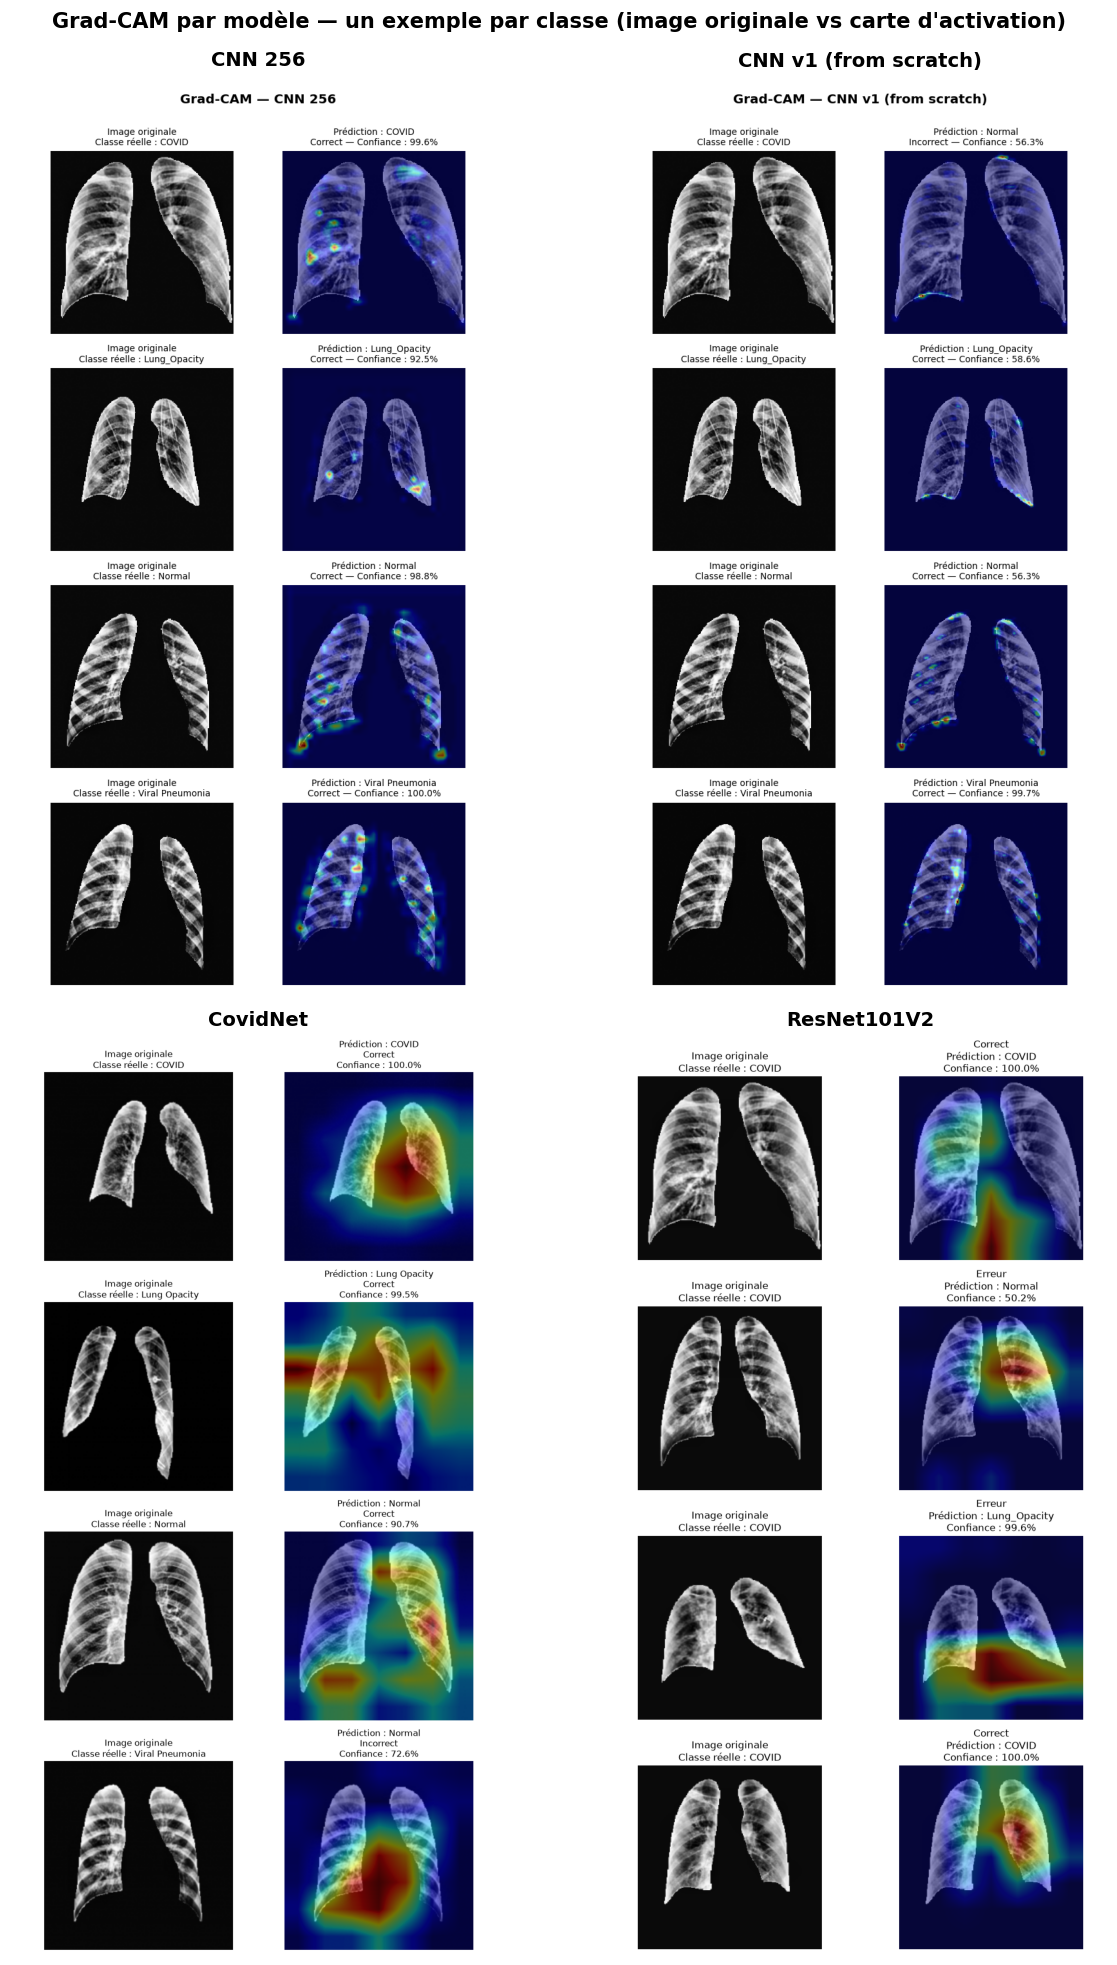

In [10]:
import matplotlib.image as mpimg

# (nom affiché, PNG dans reports/figures) — Grad-CAM disponibles
gradcams = [
    ("CNN 256",               "gradcam_cnn256.png"),      # régénéré depuis cnn_256.keras
    ("CNN v1 (from scratch)", "gradcam_cnn_v1.png"),      # régénéré depuis cnn_v1_maxime.keras
    ("CovidNet",              "gradcam_covidnet.png"),    # extrait du notebook CovidNet_scratch_v2
    ("ResNet101V2",           "gradcam_resnet101.png"),   # extrait du notebook ResNet101V2
]
FIGDIR = "../reports/figures"

fig, axes = plt.subplots(2, 2, figsize=(13, 20))
for ax, (nom, f) in zip(axes.flat, gradcams):
    ax.imshow(mpimg.imread(f"{FIGDIR}/{f}"))
    ax.set_title(nom, fontsize=14, fontweight="bold")
    ax.axis("off")

fig.suptitle("Grad-CAM par modèle — un exemple par classe (image originale vs carte d'activation)",
             fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.985])

os.makedirs(FIGDIR, exist_ok=True)
fig.savefig(f"{FIGDIR}/gradcam_planche.png", dpi=95, bbox_inches="tight")
print("planche sauvegardée -> reports/figures/gradcam_planche.png")
plt.show()